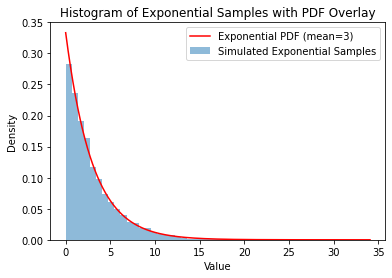

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon
np.random.seed(20251117)

#==================== Use the inverse transformation method to Sample from Exp(𝜆) ====================#

# Set the mean of the exponential distribution
mean = 3
lambda_inv = mean  # Lambda is the inverse of the mean for exponential distribution

# Number of samples
n_samples = 10000

# Step 1: Generate uniform samples
unif_samples = np.random.uniform(0, 1, n_samples)

# Step 2: Transform using the inverse of the exponential CDF
exp_samples = -lambda_inv * np.log(1 - unif_samples)

# Step 3: Plotting
# Create a histogram of the exponential samples
plt.hist(exp_samples, bins=50, alpha=0.5, label='Simulated Exponential Samples', density=True)

# Overlay the theoretical PDF of the exponential distribution
x = np.linspace(0, max(exp_samples), 1000)
pdf = expon.pdf(x, scale=lambda_inv)  # scale = 1/lambda
plt.plot(x, pdf, 'r-', label=f'Exponential PDF (mean={mean})')

# Add labels and legend
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram of Exponential Samples with PDF Overlay')
plt.legend()

# Show the plot
plt.show()

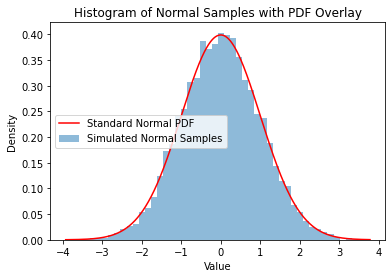

In [2]:
from scipy.stats import norm

#==================== Use the transformation method to Sample from N(0,1) ====================#

# Number of samples
n_samples = 10000

# Step 1: Generate uniform samples
unif_samples1 = np.random.uniform(0, 1, n_samples)
unif_samples2 = np.random.uniform(0, 1, n_samples)

# Step 2: Apply the transformation
norm_samples1 = np.sqrt(-2 * np.log(unif_samples1)) * np.cos(2 * np.pi * unif_samples2)
norm_samples2 = np.sqrt(-2 * np.log(unif_samples1)) * np.sin(2 * np.pi * unif_samples2)

# Step 3: Plotting
# Create a histogram of the normal samples
plt.hist(norm_samples1, bins=50, alpha=0.5, label='Simulated Normal Samples', density=True)

# Overlay the theoretical PDF of the normal distribution
x = np.linspace(min(norm_samples1), max(norm_samples1), 1000)
pdf = norm.pdf(x, loc=0, scale=1)
plt.plot(x, pdf, 'r-', label=f'Standard Normal PDF')

# Add labels and legend
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram of Normal Samples with PDF Overlay')
plt.legend()

# Show the plot
plt.show()

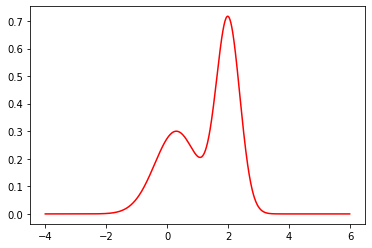

In [3]:
#==================== Example 4.6 ====================#
def fs(x):
    return 0.3 * np.exp(-(x-0.3) ** 2) + 0.7 * np.exp(-(x-2) ** 2 / 0.3)

x = np.arange(-4, 6, 0.01)

plt.plot(x, fs(x), color = 'red')

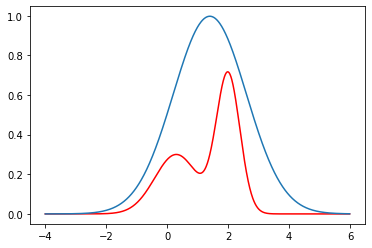

In [4]:
# Try to use a normal distribution to be the proposal distribution
# You can actually verify that it covers the target function
def gs(x, mu, sigma, c):
    return c / np.sqrt(2 * np.pi * sigma**2) * np.exp(- (x - mu)**2 / (2 * sigma**2))

plt.plot(x, fs(x), color = 'red')
plt.plot(x, gs(x, 1.4, 1.2, 3)) # by trial and error
# The proposal distribution is not unique

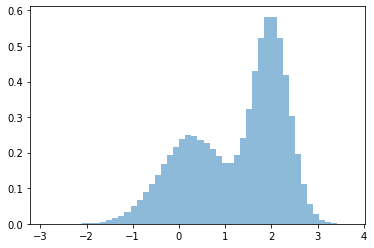

In [5]:
# Apply the rejection sampling technique
n_samples = 1000000

# Step I: sample from the proposal distribution
x_samples = np.random.normal(loc = 1.4, scale = 1.2, size = n_samples)

# Step II: sample from the uniform distribution
u_samples = np.random.uniform(0, 1, n_samples)

# Step III: compare ui with f(xi)/cg(xi) and decide whether to reject or not
accept_samples = x_samples[u_samples <= fs(x_samples) / gs(x_samples, 1.4, 1.2, 3)]
plt.hist(accept_samples, bins = 50, alpha=0.5, label='Simulated Samples from f*', density=True)
plt.show()

In [6]:
# Compute the acceptance proportion
len(accept_samples) / n_samples

0.403969